# Grundlagen der Künstlichen Intelligenz.
# Exercise 6. Random Forests

**Autor:** Arturo Olivares Martos
***

- **Asignatura:** Grundlagen der Künstlichen Intelligenz.
- **Curso Académico:** 2025-26.
- **Grado:** Doble Grado en Ingeniería Informática y Matemáticas.
- **Grupo:** Erasmus.
- **Profesor:** Gérald Kämmerer
- **Descripción:** Práctica 6 de la asignatura GKI
<!--- **Fecha:** 17 de abril de 2023. -->
<!-- - **Duración:** -->

Use the cereal dataset [cereal.csv](https://github.com/LosDelDGIIM/LosDelDGIIM.github.io/blob/main/subjects/Erasmus-DUE/GKI/Exercises/Aux/cereal.csv) to train and evaluate Random Forest Classifier and Regressor models, explore hyperparameter tuning, and visualize data relationships (Ensure this file is in the same directory as your script or provide the correct path.).

Load the `cereals.csv` dataset using Pandas.

In [68]:
# Load the dataset
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("./Aux/cereal.csv")

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Types of features
print("\nData types:")
print(df.dtypes)

# Basic statistics
print("\nDataset statistics:")
print(df.describe())

# Unique manufacturers (our classification target)
print("\nManufacturer distribution:")
print(df['mfr'].value_counts())

# Types of cereals
print("\nCereal type distribution:")
print(df['type'].value_counts())

Dataset shape: (77, 16)

First 5 rows:
                        name mfr type  calories  protein  fat  sodium  fiber  \
0                  100% Bran   N    C        70        4    1     130   10.0   
1          100% Natural Bran   Q    C       120        3    5      15    2.0   
2                   All-Bran   K    C        70        4    1     260    9.0   
3  All-Bran with Extra Fiber   K    C        50        4    0     140   14.0   
4             Almond Delight   R    C       110        2    2     200    1.0   

   carbo  sugars  potass  vitamins  shelf  weight  cups     rating  
0    5.0       6     280        25      3     1.0  0.33  68.402973  
1    8.0       8     135         0      3     1.0  1.00  33.983679  
2    7.0       5     320        25      3     1.0  0.33  59.425505  
3    8.0       0     330        25      3     1.0  0.50  93.704912  
4   14.0       8      -1        25      3     1.0  0.75  34.384843  

Missing values:
name        0
mfr         0
type        0
calorie

Perform exploratory data analysis (EDA). Generate pair plots to visualize relationships between numerical features.

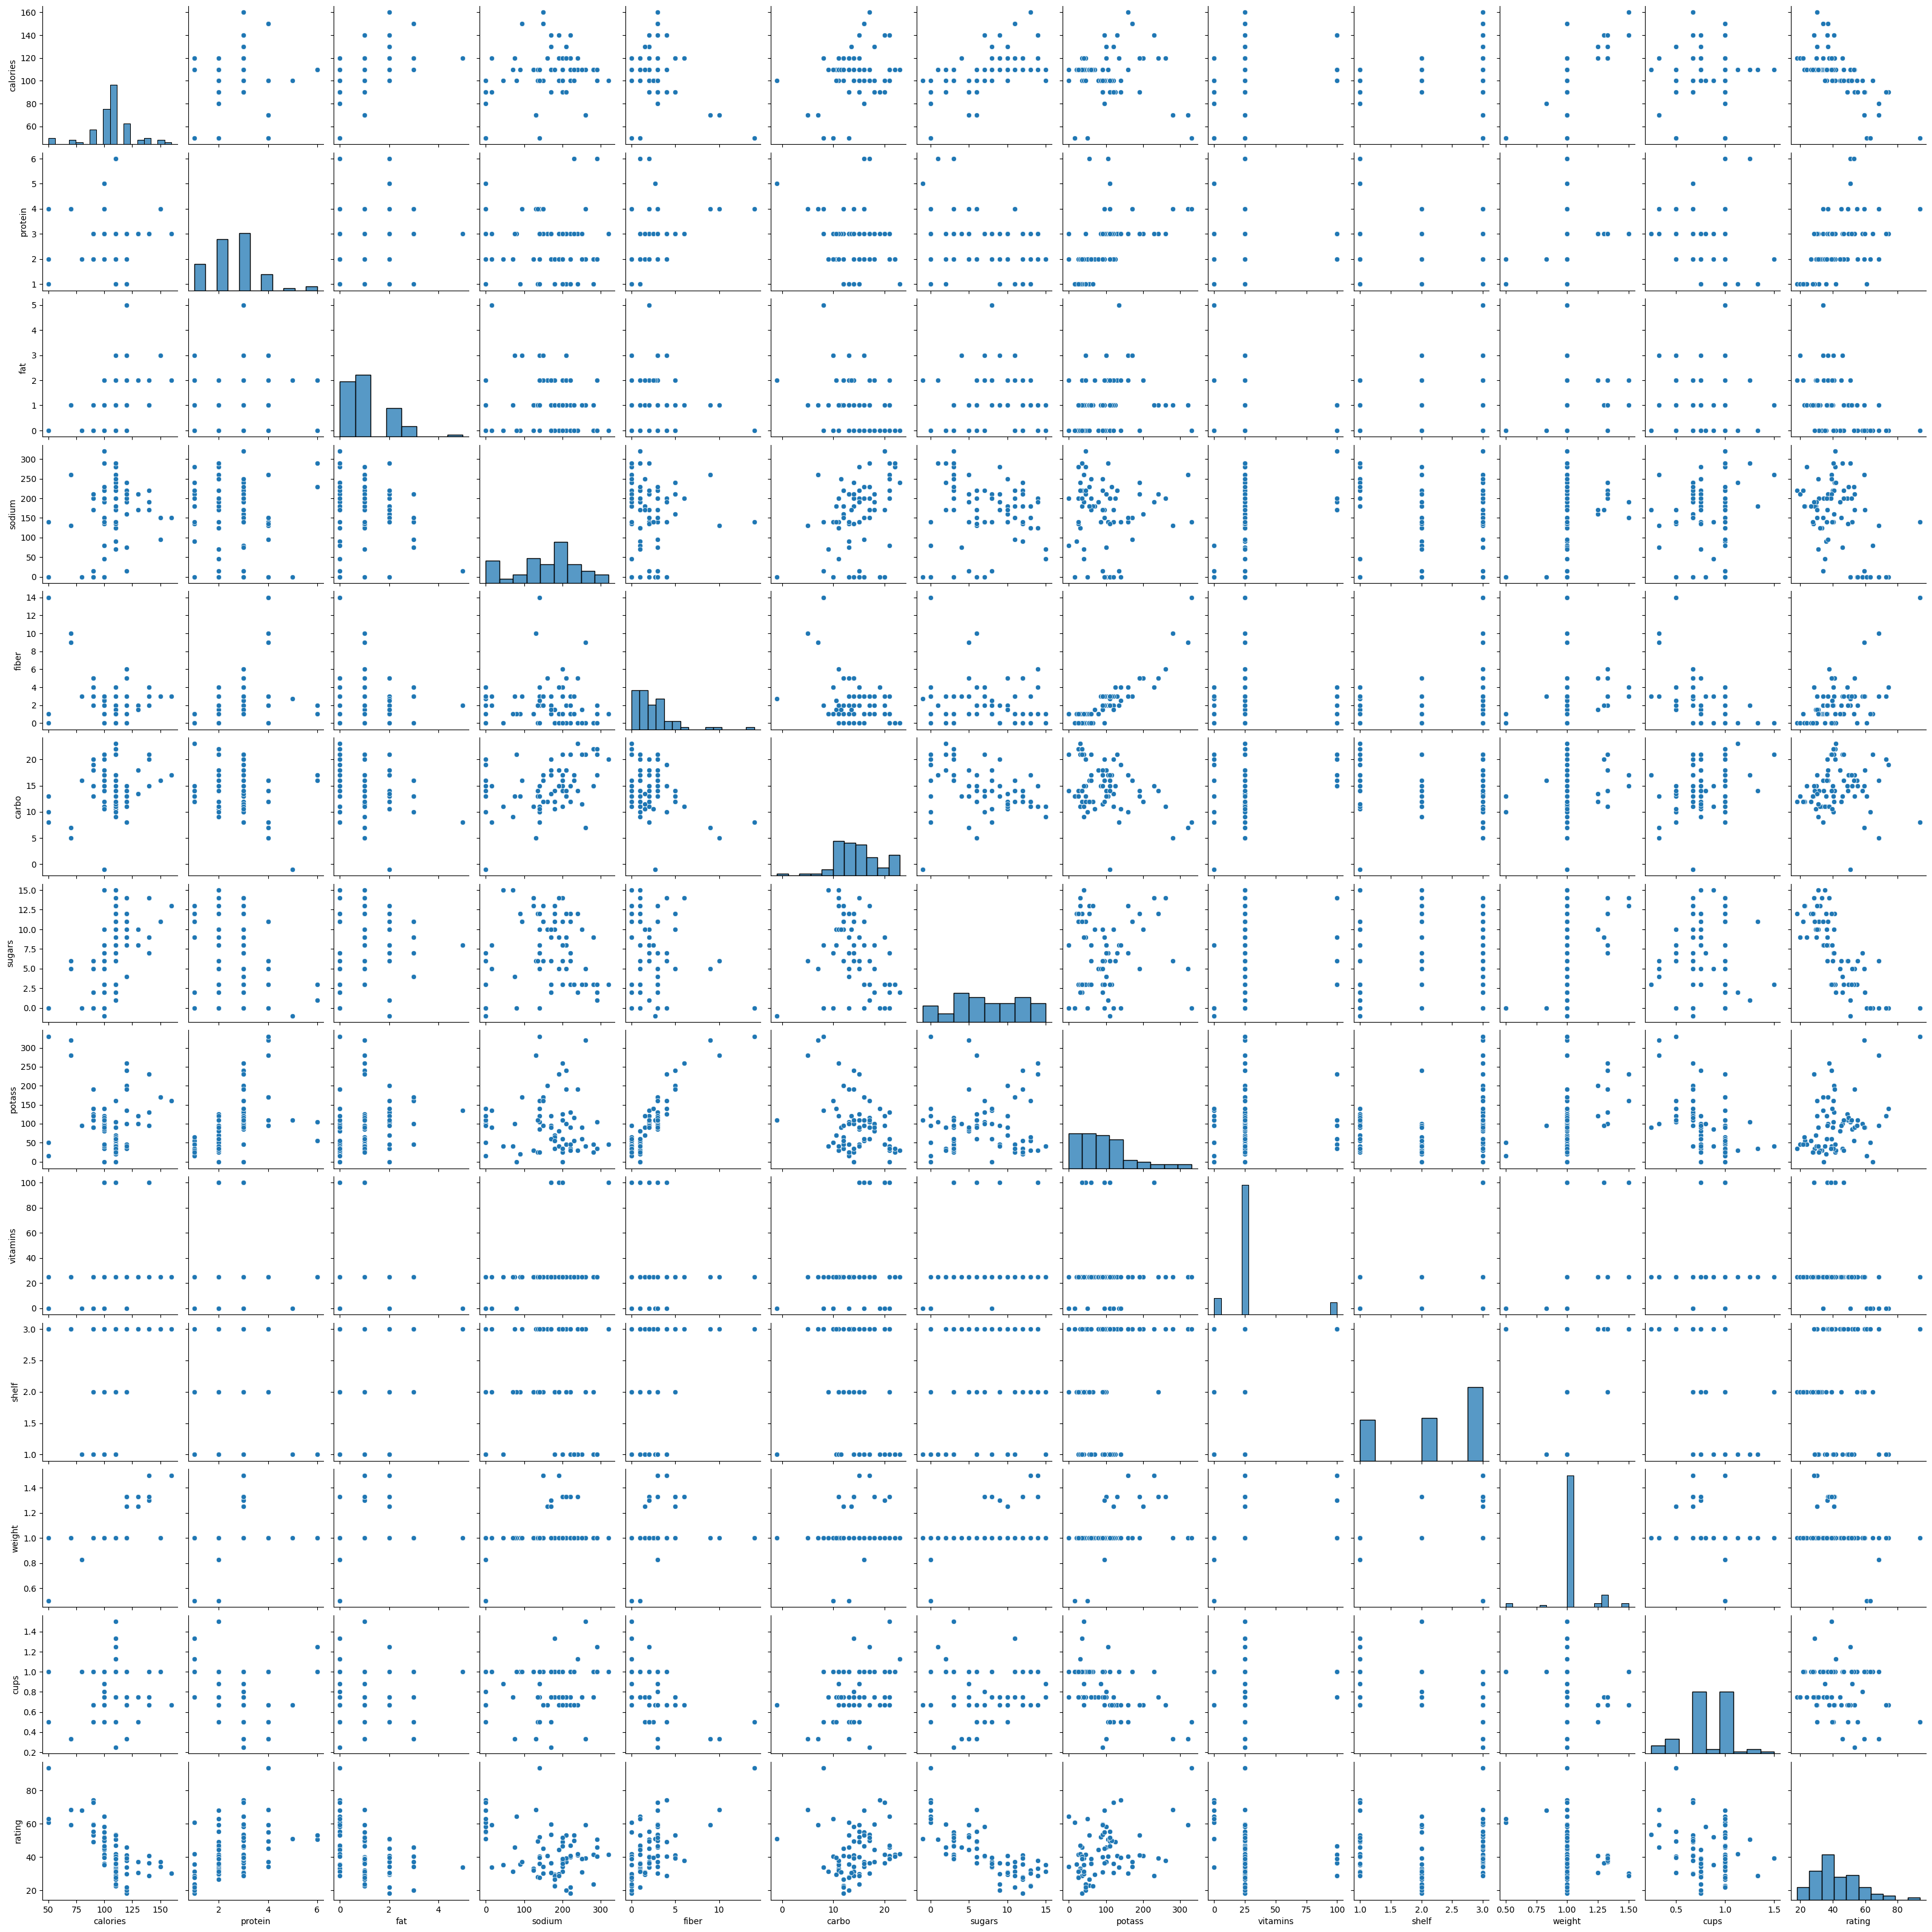

In [50]:
# Exploratory Data Analysis
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data.select_dtypes(include=['float64', 'int64']));

Preprocess the data:
- Handle categorical variables using appropriate encoding techniques.
- Split the data into training and testing sets (use a split 0.2).

In [70]:
# Preprocess the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Define your targets first
target_class_col = 'mfr'
target_reg_col = 'calories'
target_class = df[target_class_col]
target_reg = df[target_reg_col]

# Columns to drop from features
cols_to_drop = [target_class_col, target_reg_col, 'name']  # 'name' is not useful for modeling

# Encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols.drop(cols_to_drop, errors='ignore')
print("Distinct values in each categorical column:")
for col in categorical_cols:
    print(f"\t- {col}: {df[col].unique().tolist()}")

encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_cols = pd.DataFrame(
    encoder.fit_transform(df[categorical_cols]), 
    index=df.index # Keeps indices aligned
)
encoded_cols.columns = encoder.get_feature_names_out(categorical_cols)

df_features = df.drop(categorical_cols, axis=1)
features = pd.concat([df_features, encoded_cols], axis=1)
features = features.drop(cols_to_drop, axis=1, errors='ignore')

X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    features, target_class, target_reg, test_size=0.2, random_state=42
)

print("Selected features:", features.columns.tolist())
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Distinct values in each categorical column:
	- type: ['C', 'H']
Selected features: ['protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins', 'shelf', 'weight', 'cups', 'rating', 'type_H']
Training set shape: (61, 13)
Testing set shape: (16, 13)


### Classification Task
Train a Random Forest Classifier to predict a categorical variable. Experiment with different hyperparameters (Repeat the training and testing with different `n_estimators = 1, 10, 1000`, Which parameter yields the most precise results?).

In [85]:
print("Training set class distribution:")
print(y_class_train.value_counts())
print("Testing set class distribution:")
print(y_class_test.value_counts())

# Train Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


n_estimators_values = [1, 10, 1000]
rf_classifiers = {}
class_predictions = {}
accuracy_scores = {}

for n_estimators in n_estimators_values:
    classifier = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    classifier.fit(X_train, y_class_train)

    rf_classifiers[n_estimators] = classifier
    class_predictions[n_estimators] = classifier.predict(X_test)
    accuracy_scores[n_estimators] = accuracy_score(y_class_test, class_predictions[n_estimators])
    print("-" * 50)
    print(f"Random Forest with n_estimators={n_estimators}:")
    print(f"\t- Accuracy: {accuracy_scores[n_estimators]:.4f}")
    print("\t- Classification Report:")
    print(classification_report(y_class_test, class_predictions[n_estimators]))

Training set class distribution:
mfr
G    19
K    18
P     8
Q     6
R     5
N     4
A     1
Name: count, dtype: int64
Testing set class distribution:
mfr
K    5
R    3
G    3
Q    2
N    2
P    1
Name: count, dtype: int64
--------------------------------------------------
Random Forest with n_estimators=1:
	- Accuracy: 0.4375
	- Classification Report:
              precision    recall  f1-score   support

           G       0.43      1.00      0.60         3
           K       0.33      0.20      0.25         5
           N       1.00      0.50      0.67         2
           P       0.25      1.00      0.40         1
           Q       0.00      0.00      0.00         2
           R       1.00      0.33      0.50         3

    accuracy                           0.44        16
   macro avg       0.50      0.51      0.40        16
weighted avg       0.51      0.44      0.39        16

--------------------------------------------------
Random Forest with n_estimators=10:
	- Accuracy: 0.

Visualize the classification results using confusion matrices and classification reports.

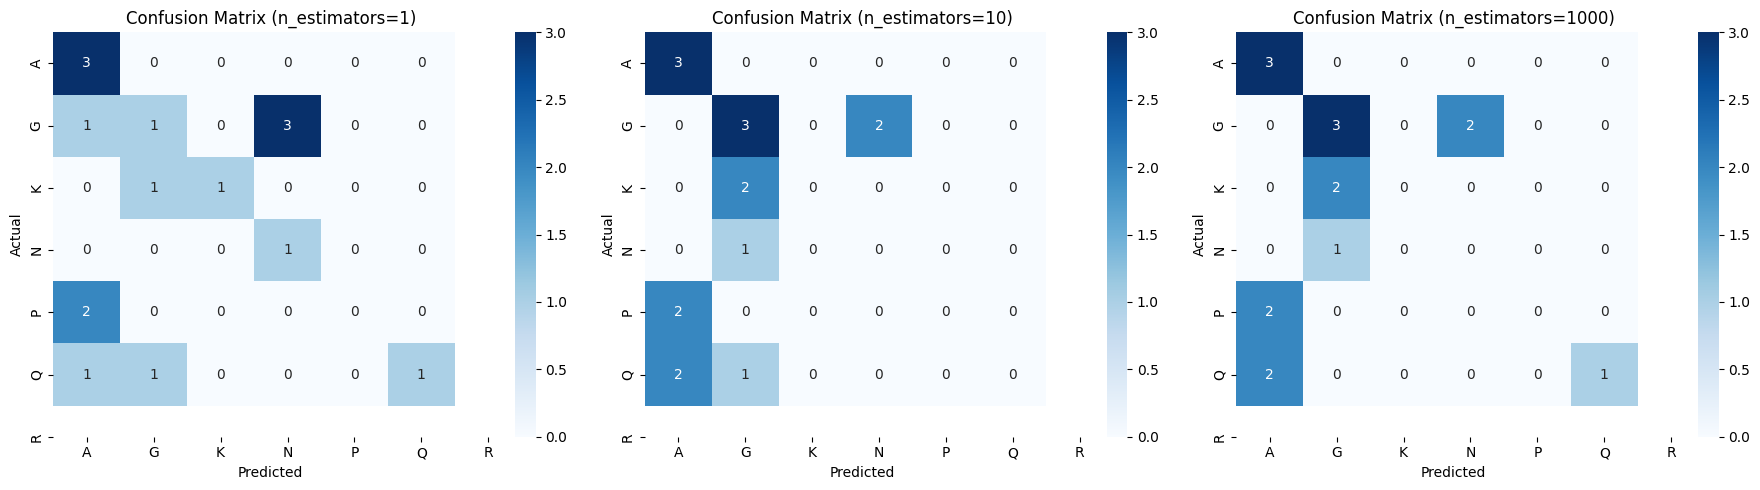

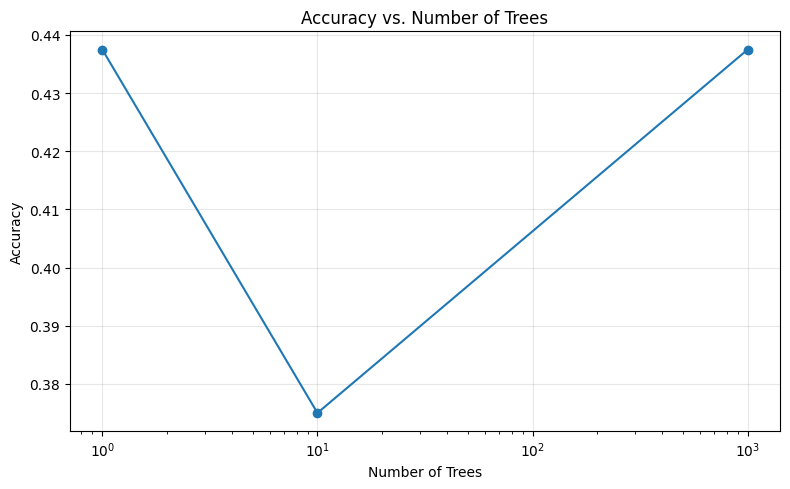

In [87]:
# Create confusion matrices for each n_estimators
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, n_trees in enumerate(n_estimators_values):
    cm = confusion_matrix(y_class_test, class_predictions[n_trees])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=rf_classifiers[n_trees].classes_,
                yticklabels=rf_classifiers[n_trees].classes_,
                ax=axes[i])
    axes[i].set_title(f'Confusion Matrix (n_estimators={n_trees})')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Compare accuracy scores across different n_estimators
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_values, [accuracy_scores[n] for n in n_estimators_values], marker='o', linestyle='-')
plt.xscale('log')
plt.title('Accuracy vs. Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Feature importance: Analyze and visualize the importance of different features in the classification task.


Feature Importances for Classifier Models:
           1 trees  10 trees  1000 trees
rating    0.117549  0.138036    0.143112
sodium    0.219875  0.097471    0.129279
potass    0.239508  0.143159    0.102981
carbo     0.000000  0.079028    0.101374
fat       0.144746  0.107603    0.095248
sugars    0.029813  0.091420    0.092561
fiber     0.045801  0.084926    0.089533
cups      0.058758  0.071552    0.068986
vitamins  0.000000  0.069043    0.061041
protein   0.062383  0.044026    0.049900
shelf     0.000000  0.043332    0.032869
weight    0.081566  0.030405    0.024882
type_H    0.000000  0.000000    0.008235


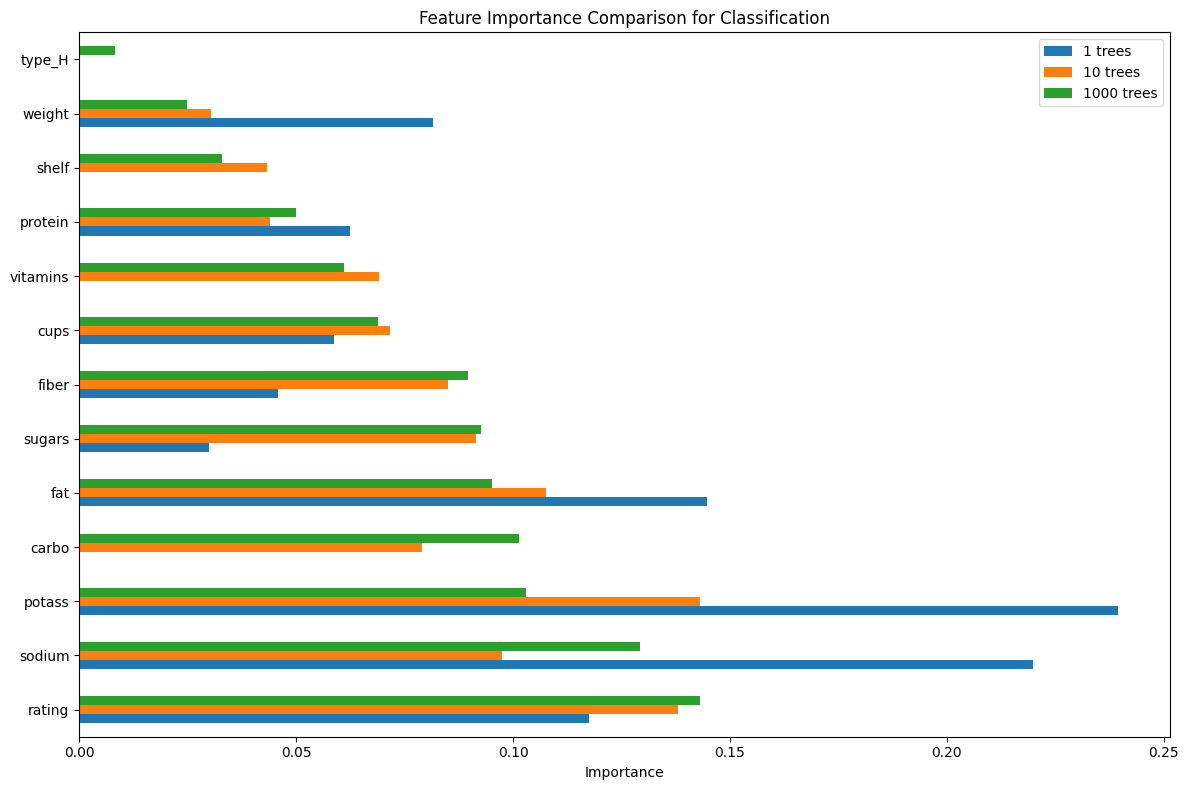

In [88]:
# Compare feature importances across different models
feature_importances = pd.DataFrame(
    {f'{n} trees': rf_classifiers[n].feature_importances_ for n in n_estimators_values},
    index=X_train.columns
)
sortering_column = f'{n_estimators_values[-1]} trees'
feature_importances = feature_importances.sort_values(by=sortering_column, ascending=False)

print("\nFeature Importances for Classifier Models:")
print(feature_importances)

# Plot feature importances
plt.figure(figsize=(12, 8))

plt.title('Feature Importance Comparison for Classification')
feature_importances.plot.barh(ax=plt.gca())
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Regression Task

Train a Random Forest Regressor to predict a numerical variable. Experiment with different hyperparameters.

In [73]:
# Train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

rf_regressors = {}
reg_predictions = {}
r2_scores = {}
mse_scores = {}
sqrt_mse_scores = {}

for n_estimators in n_estimators_values:
    regressor = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
    regressor.fit(X_train, y_reg_train)
    
    rf_regressors[n_estimators] = regressor
    reg_predictions[n_estimators] = regressor.predict(X_test)
    mse_scores[n_estimators] = mean_squared_error(y_reg_test, reg_predictions[n_estimators])
    r2_scores[n_estimators] = r2_score(y_reg_test, reg_predictions[n_estimators])
    sqrt_mse_scores[n_estimators] = sqrt(mse_scores[n_estimators])

    print(f"Regressor Performance with n_estimators={n_estimators}:")
    print(f"\t- MSE: {mse_scores[n_estimators]:.2f}")
    print(f"\t- RMSE: {sqrt_mse_scores[n_estimators]:.2f}")
    print(f"\t- R^2 Score: {r2_scores[n_estimators]:.2f}")
    print("-" * 40)

Regressor Performance with n_estimators=1:
	- MSE: 293.75
	- RMSE: 17.14
	- R^2 Score: 0.02
----------------------------------------
Regressor Performance with n_estimators=10:
	- MSE: 68.75
	- RMSE: 8.29
	- R^2 Score: 0.77
----------------------------------------
Regressor Performance with n_estimators=1000:
	- MSE: 64.98
	- RMSE: 8.06
	- R^2 Score: 0.78
----------------------------------------


Visualize the Regression Results


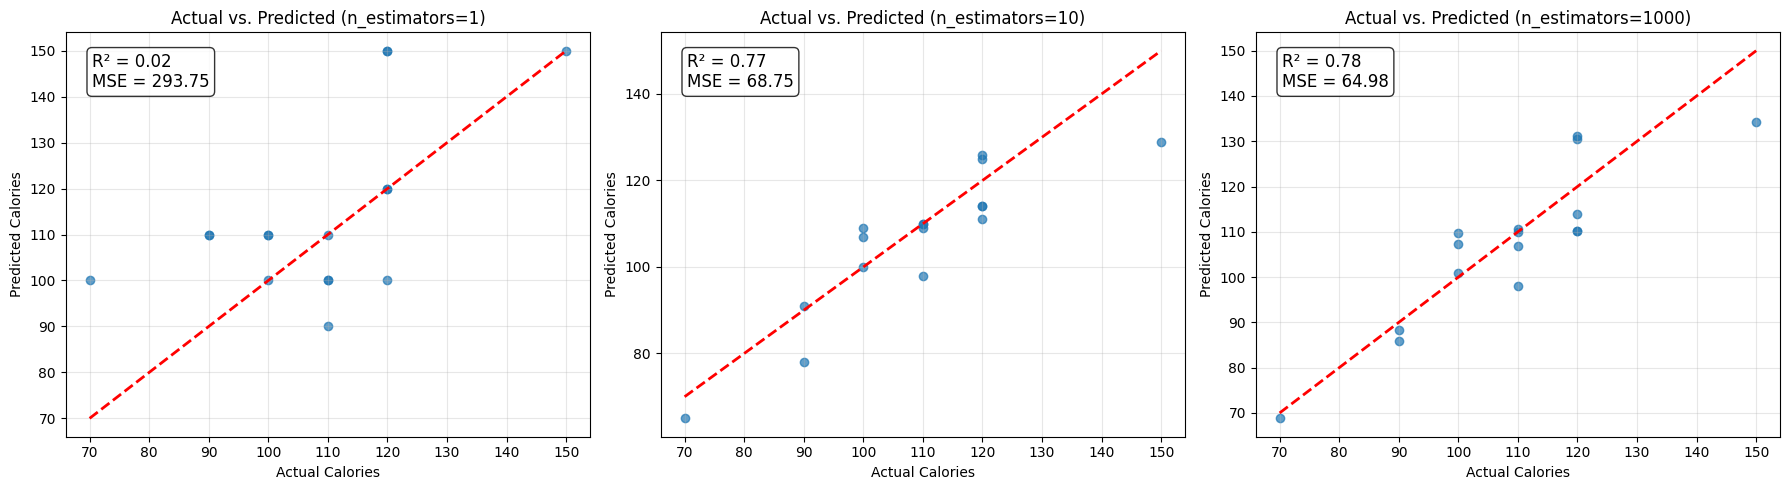

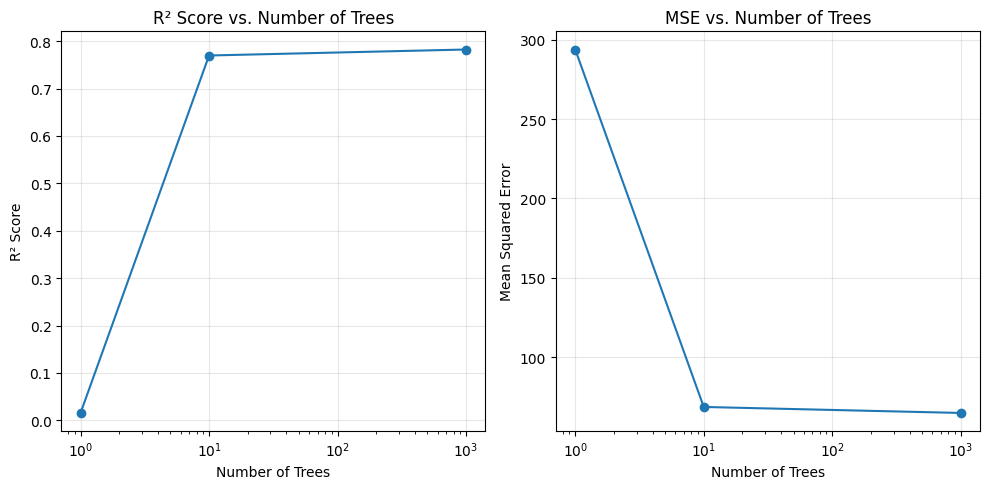

In [ ]:
# Create a figure with subplots for predicted vs actual values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, n_trees in enumerate(n_estimators_values):
    axes[i].scatter(y_reg_test, reg_predictions[n_trees], alpha=0.7)
    axes[i].plot([y_reg_test.min(), y_reg_test.max()], 
             [y_reg_test.min(), y_reg_test.max()], 
             'r--', lw=2)
    axes[i].set_xlabel('Actual Calories')
    axes[i].set_ylabel('Predicted Calories')
    axes[i].set_title(f'Actual vs. Predicted (n_estimators={n_trees})')
    axes[i].text(0.05, 0.95, f'R² = {r2_scores[n_trees]:.2f}\nMSE = {mse_scores[n_trees]:.2f}', 
              transform=axes[i].transAxes, fontsize=12,
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare R² and MSE values across different n_estimators
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(n_estimators_values, [r2_scores[n] for n in n_estimators_values], marker='o', linestyle='-')
plt.xscale('log')
plt.title('R² Score vs. Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('R² Score')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(n_estimators_values, [mse_scores[n] for n in n_estimators_values], marker='o', linestyle='-')
plt.xscale('log')
plt.title('MSE vs. Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Mean Squared Error')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Analyze the feature importance from the Random Forest models.


Feature Importances for Regressor Models:
           1 trees  10 trees  1000 trees
rating    0.089978  0.451133    0.417882
weight    0.421398  0.236365    0.272567
potass    0.015802  0.041510    0.083433
carbo     0.000000  0.056312    0.078419
fiber     0.000000  0.018156    0.027332
sugars    0.257112  0.075753    0.024359
sodium    0.014505  0.018293    0.023613
fat       0.181248  0.027826    0.021614
shelf     0.000000  0.050699    0.019852
protein   0.000000  0.005802    0.015183
cups      0.016405  0.014340    0.013176
vitamins  0.003552  0.000961    0.001797
type_H    0.000000  0.002850    0.000774


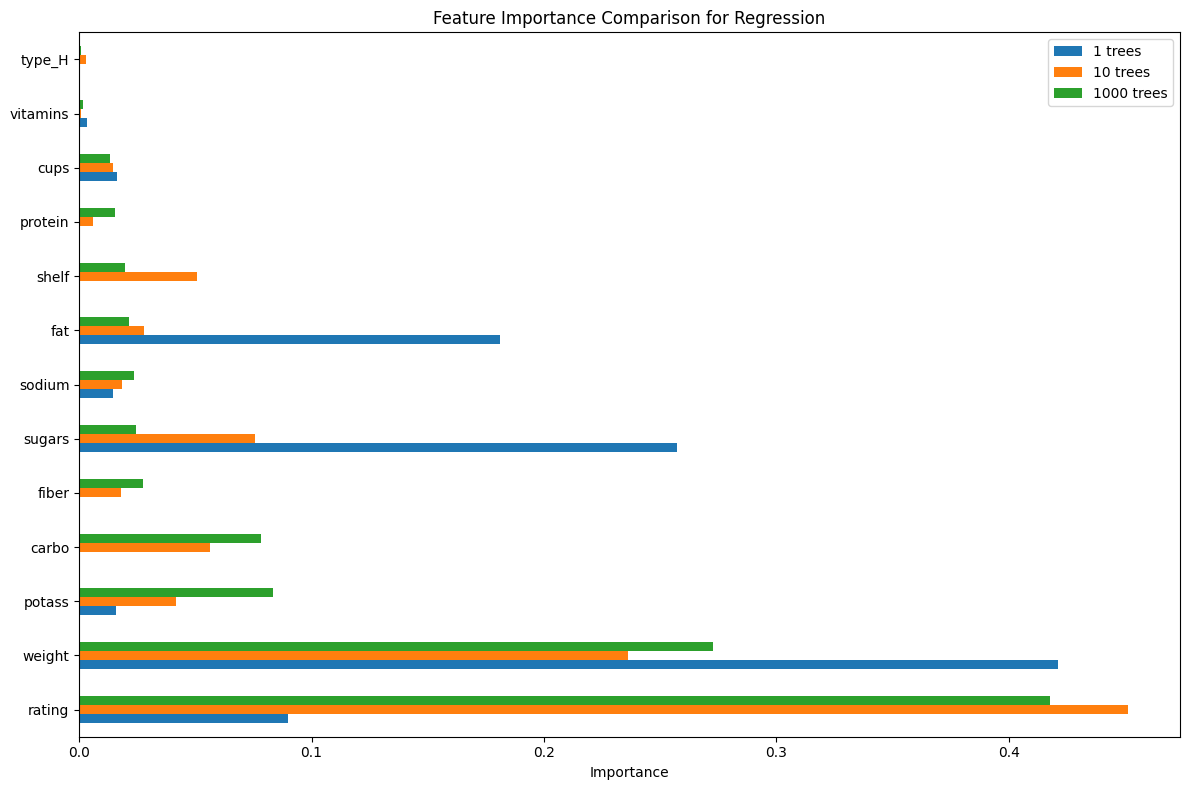

In [84]:
# Compare feature importances across different models
feature_importances = pd.DataFrame(
    {f'{n} trees': rf_regressors[n].feature_importances_ for n in n_estimators_values},
    index=X_train.columns
)
sortering_column = f'{n_estimators_values[-1]} trees'
feature_importances = feature_importances.sort_values(by=sortering_column, ascending=False)

print("\nFeature Importances for Regressor Models:")
print(feature_importances)

# Plot feature importances
plt.figure(figsize=(12, 8))

plt.title('Feature Importance Comparison for Regression')
feature_importances.plot.barh(ax=plt.gca())
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Bonus

Experiment with hyperparameter tuning using techniques such as `GridSearchCV` or `RandomizedSearchCV`.

Best Regressor Hyperparameters: {'n_estimators': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
Best Regressor Performance:
	- MSE: 68.75
	- R^2 Score: 0.77


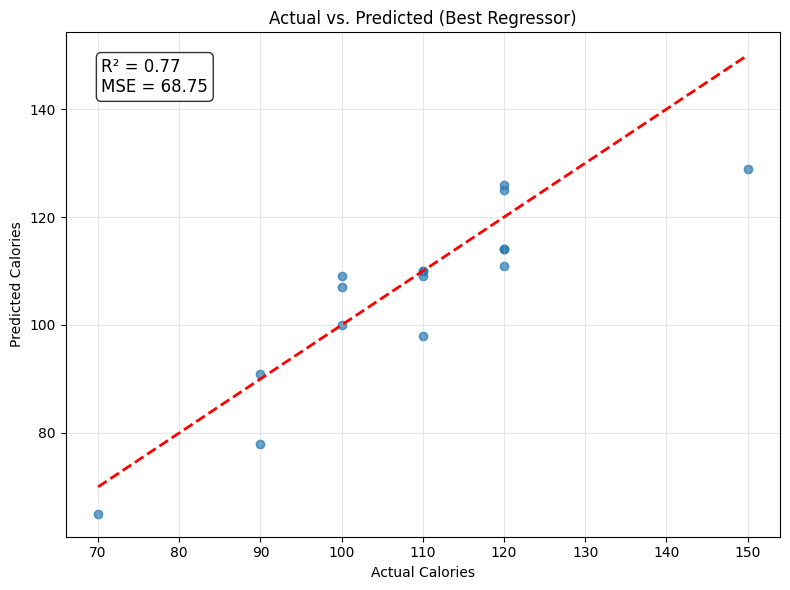

In [91]:
# Hyperparameter Tuning (Example with RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [10, 50, 100, 500, 1000],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Evaluate the best regressor using RandomizedSearchCV
grid_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, n_iter=20, random_state=42)
grid_search.fit(X_train, y_reg_train)
print("Best Regressor Hyperparameters:", grid_search.best_params_)
best_regressor = grid_search.best_estimator_

# Evaluate the best regressor on the test set
best_predictions = best_regressor.predict(X_test)
best_mse = mean_squared_error(y_reg_test, best_predictions)
best_r2 = r2_score(y_reg_test, best_predictions)
print(f"Best Regressor Performance:")
print(f"\t- MSE: {best_mse:.2f}")
print(f"\t- R^2 Score: {best_r2:.2f}")

# Visualize the best regressor's predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, best_predictions, alpha=0.7)
plt.plot([y_reg_test.min(), y_reg_test.max()], 
         [y_reg_test.min(), y_reg_test.max()], 
         'r--', lw=2)
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('Actual vs. Predicted (Best Regressor)')
plt.text(0.05, 0.95, f'R² = {best_r2:.2f}\nMSE = {best_mse:.2f}',
            transform=plt.gca().transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Best Classifier Hyperparameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Best Classifier Performance:
	- Accuracy: 0.3125
	- Classification Report:
              precision    recall  f1-score   support

           G       0.30      1.00      0.46         3
           K       0.40      0.40      0.40         5
           N       0.00      0.00      0.00         2
           P       0.00      0.00      0.00         1
           Q       0.00      0.00      0.00         2
           R       0.00      0.00      0.00         3

    accuracy                           0.31        16
   macro avg       0.12      0.23      0.14        16
weighted avg       0.18      0.31      0.21        16



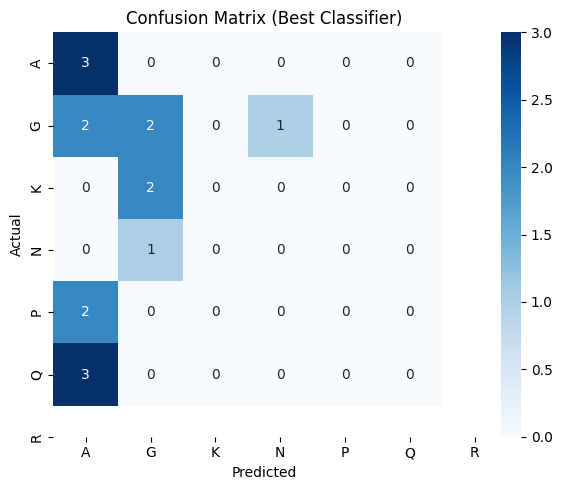

In [92]:
# Evaluate the best classifier using RandomizedSearchCV
grid_search_class = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_iter=20, random_state=42)
grid_search_class.fit(X_train, y_class_train)
print("Best Classifier Hyperparameters:", grid_search_class.best_params_)
best_classifier = grid_search_class.best_estimator_

# Evaluate the best classifier on the test set
best_class_predictions = best_classifier.predict(X_test)
best_accuracy = accuracy_score(y_class_test, best_class_predictions)
print(f"Best Classifier Performance:")
print(f"\t- Accuracy: {best_accuracy:.4f}")
print("\t- Classification Report:")
print(classification_report(y_class_test, best_class_predictions))

# Create confusion matrix for the best classifier
cm = confusion_matrix(y_class_test, best_class_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_classifier.classes_,
            yticklabels=best_classifier.classes_)
plt.title('Confusion Matrix (Best Classifier)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()